In [2]:
import pandas as pd
import numpy as np

# Load the dataset
# Ensure 'Titanic.csv' is in the same folder as your script
df = pd.read_csv('Titanic.csv')

# 1. HANDLING MISSING VALUES (Slide 8)
# Fill missing 'Age' with the Median (robust to outliers)
df['Age'] = df['Age'].fillna(df['Age'].median())

# Fill missing 'Embarked' with the Mode (most common value)
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# For 'Cabin', since many values are missing, we can fill with 'Unknown'
df['Cabin'] = df['Cabin'].fillna('Unknown')

# 2. CORRECTING INCONSISTENT DATA (Slide 8)
# Ensure categorical data is consistent (e.g., stripping whitespace)
df['Sex'] = df['Sex'].str.strip().str.lower()

# 3. IDENTIFYING OUTLIERS (Slide 8)
# Example: If Fare is 0 or negative, we might treat it as a missing value
df.loc[df['Fare'] <= 0, 'Fare'] = df['Fare'].median()

# 4. FINAL CHECK
print("Missing values after cleaning:")
print(df.isnull().sum())

# Save the cleaned data
df.to_csv('Titanic_Cleaned.csv', index=False)
print("\nCleaned file saved as 'Titanic_Cleaned.csv'")

Missing values after cleaning:
PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Cabin          0
Embarked       0
dtype: int64

Cleaned file saved as 'Titanic_Cleaned.csv'


Data loaded successfully!


C:\Users\zicoo\AppData\Local\Temp\ipykernel_20084\3017554206.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Survived', y='Fare', palette='Set1')


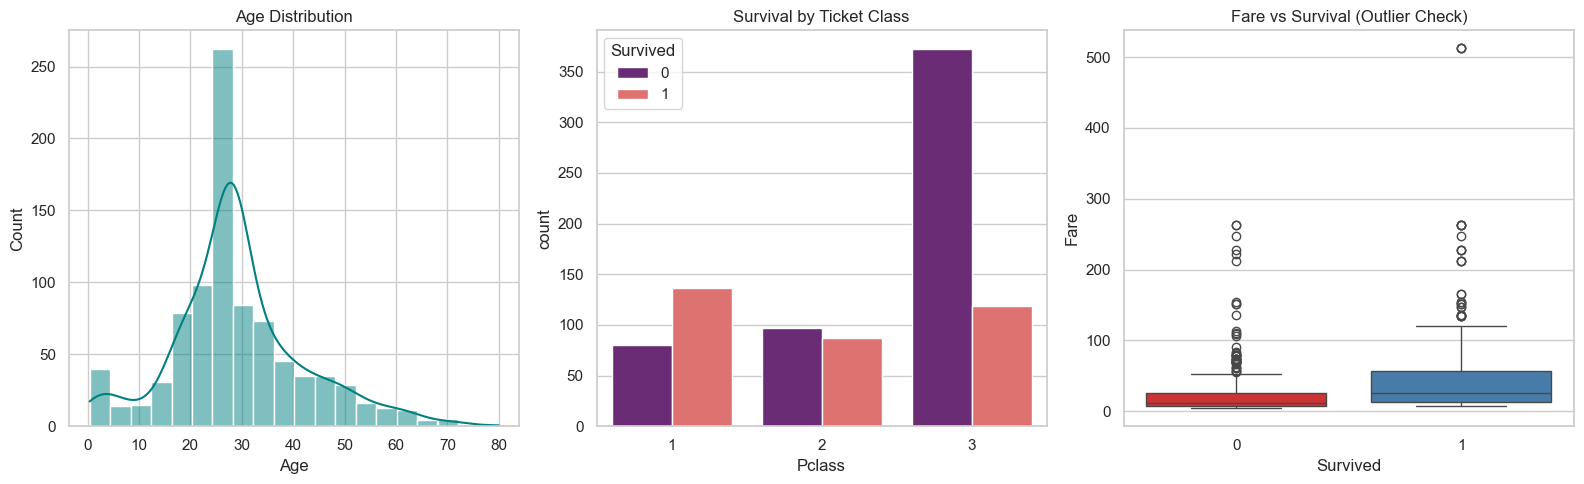


--- Summary Statistics ---
            Age       Fare
mean  29.361582  32.447545
50%   28.000000  14.454200


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

file_name = 'Titanic.csv'

if not os.path.exists(file_name):
    print(f"ERROR: '{file_name}' not found. Please ensure the file is in this folder.")
else:
    df = pd.read_csv(file_name)
    print("Data loaded successfully!")

    # 1. Fill missing numerical values with Median [cite: 103, 104]
    if 'Age' in df.columns:
        df['Age'] = df['Age'].fillna(df['Age'].median())
    
    # 2. Fill missing categorical values with Mode [cite: 104]
    if 'Embarked' in df.columns:
        df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

    # 3. Handle 'Dirty Data' / Outliers [cite: 99, 105]
    if 'Fare' in df.columns:
        # Replacing 0 or negative fares with the median to smooth noisy data [cite: 105]
        df.loc[df['Fare'] <= 0, 'Fare'] = df['Fare'].median()


    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(16, 5))

    # Visualization 1: Histogram (Distribution of Age) [cite: 110, 122]
    plt.subplot(1, 3, 1)
    sns.histplot(df['Age'], bins=20, kde=True, color='teal')
    plt.title('Age Distribution')

    # Visualization 2: Countplot (Survival by Class) [cite: 113, 124]
    plt.subplot(1, 3, 2)
    sns.countplot(data=df, x='Pclass', hue='Survived', palette='magma')
    plt.title('Survival by Ticket Class')

    # Visualization 3: Boxplot (Fare Outliers) [cite: 111, 123]
    plt.subplot(1, 3, 3)
    sns.boxplot(data=df, x='Survived', y='Fare', palette='Set1')
    plt.title('Fare vs Survival (Outlier Check)')

    plt.tight_layout()
    plt.show()

    #  STEP 4: SUMMARY STATISTICS [cite: 115, 116] 
    print("\n--- Summary Statistics ---")
    print(df[['Age', 'Fare']].describe().loc[['mean', '50%']]) # 50% is the Median [cite: 116]